# Final Project - DD2358
## Navier-Stokes Solver Optimization
Axel Ericson Holmgren, Jonathan Fransson, Kasper Malm

## Profiling
=====================================================================================

### cProfile

In [1]:
# cProfiling, printing cumulative time to file cprofiling-ns.txt
# !python profiling-original-code\computation\cprofile\cprofiling-ns.py

navier_stokes_spectral.py:88: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


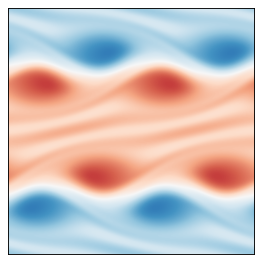

<Figure size 640x480 with 0 Axes>

         2065833 function calls (2049561 primitive calls) in 51.534 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    23/22    0.000    0.000   51.542    2.343 base_events.py:1966(_run_once)
       22    4.184    0.190   51.535    2.343 selectors.py:540(select)
    27000    1.269    0.000   39.419    0.001 _pocketfft.py:741(_raw_fftnd)
    54000   37.921    0.001   37.951    0.001 _pocketfft.py:58(_raw_fft)
    15000    0.013    0.000   20.972    0.001 _pocketfft.py:887(ifftn)
    30000    0.021    0.000   20.320    0.001 _pocketfft.py:219(ifft)
    12000    0.011    0.000   18.476    0.002 _pocketfft.py:755(fftn)
    24000    0.019    0.000   17.677    0.001 _pocketfft.py:120(fft)
     3000    2.584    0.001   15.910    0.005 navier_stokes_spectral.py:31(grad)
     1000    1.358    0.001    7.126    0.007 navier_stokes_spectral.py:39(div)
     1000    1.314    0.001    6.977    0.007 navier_stokes_spectral.py:46(curl)


In [2]:
%run -m cProfile -s cumtime navier_stokes_spectral.py

### Line_profiler

In [3]:
%run -m kernprof -l -v -o profiling-original-code/computation/line_profiler/line_profiling-ns.py.lprof profiling-original-code/computation/line_profiler/line_profiling-ns.py

profiling-original-code/computation/line_profiler/line_profiling-ns.py:96: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002
Wrote profile results to 'profiling-original-code/computation/line_profiler/line_profiling-ns.py.lprof'
Timer unit: 1e-06 s

Total time: 0.029909 s
File: profiling-original-code/computation/line_profiler/line_profiling-ns.py
Function: poisson_solve at line 17

Line #      Hits         Time  Per Hit   % Time  Line Contents
    17                                           @profile
    18                                           def poisson_solve(rho, kSq_inv):
    19                                               """solve the Poisson equation, given source field rho"""
    20        10      16773.0   1677.3     56.1      V_hat = -(np.fft.fftn(rho)) * kSq_inv
    21        10      13133.0   1313.3     43.9      V = np.real(np.fft.ifftn(V_hat))
    22        10          3.0      0.3      0.0      return V

Total time: 0.066181 s
File: profiling-original-code/computation/line_profiler/line_profiling-ns

### Memory_Profiler

Memory_Profiler output in notebook

In [4]:
%run -m memory_profiler profiling-original-code/memory/memory_profiler/memory_profiling-ns.py

0.001


/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
profiling-original-code/memory/memory_profiler/memory_profiling-ns.py:102: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002
Filename: profiling-original-code/memory/memory_profiler/memory_profiling-ns.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    66  284.594 MiB  284.594 MiB           1   @profile
    67                                         def main():
    68                                             """Navier-Stokes Simulation"""
    69                                         
    70                                             # Simulation parameters
    71  284.531 MiB   -0.062 MiB           1       N = 400  # Spatial resolution
    72  284.531 MiB    0.000 MiB           1       t = 0  # current time of the simulation
    73                                         
    74                                             # Changed for testing:
    75                                             # tEnd = 1  # time at which simulation ends
    76  284.531 MiB    0.000 MiB           1       tEnd = 0.01  

Memory_Profiler output to .txt file

In [5]:
%run -m memory_profiler profiling-original-code/memory/memory_profiler/memory_profiling-ns.py 2>&1 > profiling-original-code/memory/memory_profiler/memory_profile_ns.txt

0.001
0.002
0.003


/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
profiling-original-code/memory/memory_profiler/memory_profiling-ns.py:102: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002
Filename: profiling-original-code/memory/memory_profiler/memory_profiling-ns.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    66  274.203 MiB  274.203 MiB           1   @profile
    67                                         def main():
    68                                             """Navier-Stokes Simulation"""
    69                                         
    70                                             # Simulation parameters
    71  274.203 MiB    0.000 MiB           1       N = 400  # Spatial resolution
    72  274.203 MiB    0.000 MiB           1       t = 0  # current time of the simulation
    73                                         
    74                                             # Changed for testing:
    75                                             # tEnd = 1  # time at which simulation ends
    76  274.203 MiB    0.000 MiB           1       tEnd = 0.01  # time at wh

In [6]:
# Running and saving in correct folder
# %cd profiling-original-code/memory/memory_profiler
!: > profiling-original-code/memory/memory_profiler/memory_profile.dat

%run -m mprof run -o profiling-original-code/memory/memory_profiler/memory_profile.dat profiling-original-code/memory/memory_profiler/memory_profiling-ns.py 

mprof.py: Sampling memory every 0.1s
running new process
running as a Python program...


profiling-original-code/memory/memory_profiler/memory_profiling-ns.py:102: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.010000000000000002


In [7]:
# Running and saving in the correct folder
%run -m mprof plot profiling-original-code/memory/memory_profiler/memory_profile.dat -o profiling-original-code/memory/memory_profiler/memory_plot.png

## Optimization
=====================================================================================

### Cython compiled code

Done: 

Baseline without pyfftw: 

    cProfile: 50.8 s 

Created Cython framwork.
Type annotation for varibles
Changed fft backend to pyfftw with numpy wrappers. 
Added more aggressive compile arguments in setup.py

    cProfile: 47 to 48s 

Python with pyfftw:

    cProfile: 20.2 s 

Python native numpy with updated algo (reduce FFT calls per timestep). transition to keeping vx/vy_hat (Fourier space) as the evolving state and only transforming to realspace when doing non linear products. Diffusion in Fourier space. This reduces fft/ifft calls from 27 to 8 per timestep. 

    cProfile: 21.8 s 

https://math.stanford.edu/~ryzhik/notes-256B-24.pdf
https://www.sciencedirect.com/science/article/pii/0168927495001336
Optimized algorithm with vorticity formulation

    cProfile: 12.1 s 

Optimized algorithm with pyfftw numpy to pyfftw interface.
    
    cProfile: 17.4 s

Optimized algorithm with vorticity formulation and with pyfftw numpy to pyfftw interface.

    cProfile: 11.2 s 

Optimized algorithm with vorticity formulation and with planned pyfftw.

    cProfile: 11.3 s 






In [1]:
%run cython/setup.py build_ext --build-lib cython/build/ --build-temp cython/build/
#%run cython/setup.py build_ext --help

running build_ext
building 'navier_stokes_spectral_c' extension
/opt/homebrew/opt/llvm/bin/clang -fno-strict-overflow -Wsign-compare -Wunreachable-code -DNDEBUG -O2 -Wall -fPIC -O2 -isystem /opt/homebrew/Caskroom/miniforge/base/envs/HPC/include -arch arm64 -fPIC -O2 -isystem /opt/homebrew/Caskroom/miniforge/base/envs/HPC/include -arch arm64 -I/opt/homebrew/opt/libomp/include -I/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib/python3.14/site-packages/numpy/_core/include -I/opt/homebrew/Caskroom/miniforge/base/envs/HPC/include/python3.14 -c cython/navier_stokes_spectral_c.c -o cython/build/cython/navier_stokes_spectral_c.o -O3 -ffast-math -march=native
/opt/homebrew/opt/llvm/bin/clang -bundle -undefined dynamic_lookup -Wl,-rpath,/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib -L/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib -Wl,-rpath,/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib -L/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib -L/opt/homebrew/opt/libomp/lib -Wl,-rpath,

ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib' ignored
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniforge/base/envs/HPC/lib' ignored


Analysis of Python and C interplay

In [2]:
from IPython.display import HTML
%run -m cython -a cython/navier_stokes_spectral_c.pyx
HTML(filename="cython/navier_stokes_spectral_c.html")

#### cProfile for C complied code

cython/navier_stokes_spectral.py:21: RuntimeWarning: divide by zero encountered in divide
  return ns_c.main()


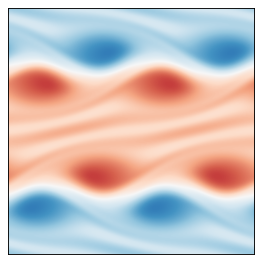

<Figure size 640x480 with 0 Axes>

         1690571 function calls (1675948 primitive calls) in 51.528 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       21    0.132    0.006   51.144    2.435 base_events.py:1966(_run_once)
       21    0.007    0.000   50.607    2.410 selectors.py:540(select)
  934/933   13.231    0.014   49.671    0.053 {built-in method time.sleep}
    27000   34.915    0.001   35.162    0.001 _utils.py:52(_Xfftn)
    15000    0.291    0.000   20.690    0.001 numpy_fft.py:281(ifftn)
    12000    1.236    0.000   16.692    0.001 numpy_fft.py:246(fftn)
       21    0.284    0.014    1.072    0.051 {method 'control' of 'select.kqueue' objects}
   552/15    0.000    0.000    0.951    0.063 <frozen importlib._bootstrap>:483(_call_with_frames_removed)
       21    0.001    0.000    0.700    0.033 __init__.py:1(<module>)
    173/9    0.000    0.000    0.626    0.070 <frozen importlib._bootstrap_external>:753(exec_module)
    202/8    0.001 

In [3]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral.py

cython/navier_stokes_spectral_pyfftw_big_main.py:63: RuntimeWarning: divide by zero encountered in divide
  kSq_inv = 1.0 / kSq


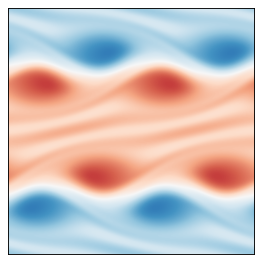

<Figure size 640x480 with 0 Axes>

         512892 function calls (512012 primitive calls) in 23.736 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       15    0.028    0.002   39.319    2.621 base_events.py:1966(_run_once)
  432/430    4.993    0.012   23.460    0.055 {built-in method time.sleep}
    27000   18.040    0.001   18.383    0.001 _utils.py:52(_Xfftn)
       14    0.003    0.000   15.209    1.086 selectors.py:540(select)
    15000    0.055    0.000   12.127    0.001 numpy_fft.py:421(irfft2)
      2/1    0.004    0.002    8.322    8.322 {built-in method builtins.exec}
        1    0.001    0.001    8.322    8.322 navier_stokes_spectral_pyfftw_big_main.py:1(<module>)
    12000    0.235    0.000    7.255    0.001 numpy_fft.py:386(rfft2)
        1    0.064    0.064    0.445    0.445 navier_stokes_spectral_pyfftw_big_main.py:26(main)
       15    0.003    0.000    0.205    0.014 events.py:92(_run)
       14    0.021    0.001    0.088    0.006 {met

In [4]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_big_main.py

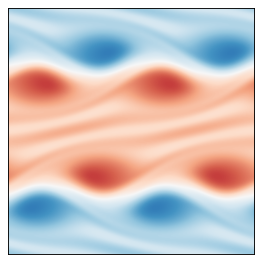

<Figure size 640x480 with 0 Axes>

         287367 function calls (286491 primitive calls) in 18.929 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.006    0.003   18.929   18.929 {built-in method builtins.exec}
      2/1    0.026    0.013   18.905   18.905 navier_stokes_spectral_algo_optim.py:1(<module>)
  351/350    4.134    0.012   18.791    0.054 {built-in method time.sleep}
     8003    0.332    0.000   11.494    0.001 _pocketfft.py:741(_raw_fftnd)
    16006   10.978    0.001   10.988    0.001 _pocketfft.py:58(_raw_fft)
     6001    0.007    0.000    8.577    0.001 _pocketfft.py:887(ifftn)
    12002    0.012    0.000    8.355    0.001 _pocketfft.py:219(ifft)
     2000    0.918    0.000    6.600    0.003 navier_stokes_spectral_algo_optim.py:32(grad)
     2000    0.514    0.000    3.419    0.002 navier_stokes_spectral_algo_optim.py:49(apply_dealias)
     2002    0.002    0.000    2.929    0.001 _pocketfft.py:755(fftn)
     4004    0.004  

In [5]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_algo_optim.py

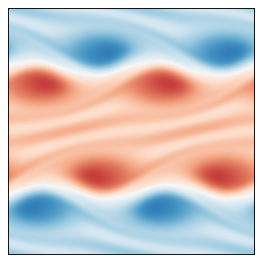

<Figure size 640x480 with 0 Axes>

         195172 function calls (194296 primitive calls) in 17.307 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  239/238    3.282    0.014   12.621    0.053 {built-in method time.sleep}
      2/1    0.000    0.000    8.266    8.266 {built-in method builtins.exec}
      2/1    4.541    2.270    8.266    8.266 navier_stokes_spectral_algo_optim_vortex.py:1(<module>)
     5002    0.156    0.000    6.582    0.001 _pocketfft.py:741(_raw_fftnd)
    10004    6.332    0.001    6.338    0.001 _pocketfft.py:58(_raw_fft)
     3000    0.003    0.000    3.886    0.001 _pocketfft.py:887(ifftn)
     6000    0.005    0.000    3.812    0.001 _pocketfft.py:219(ifft)
     2000    0.501    0.000    3.187    0.002 navier_stokes_spectral_algo_optim_vortex.py:49(apply_dealias)
     2002    0.002    0.000    2.701    0.001 _pocketfft.py:755(fftn)
     4004    0.004    0.000    2.583    0.001 _pocketfft.py:120(fft)
     1000    0.557    0.001  

In [31]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_algo_optim_vortex.py

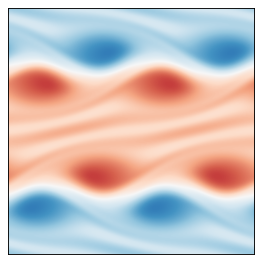

<Figure size 640x480 with 0 Axes>

         195353 function calls (194477 primitive calls) in 18.896 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.005    0.003   18.896   18.896 {built-in method builtins.exec}
  349/348    4.626    0.013   18.305    0.053 {built-in method time.sleep}
      2/1    0.062    0.031   16.177   16.177 navier_stokes_spectral_pyfftw_algo_optim.py:1(<module>)
     8003   10.138    0.001   10.206    0.001 _utils.py:52(_Xfftn)
     6001    0.024    0.000    7.946    0.001 numpy_fft.py:281(ifftn)
     2000    0.983    0.000    6.230    0.003 navier_stokes_spectral_pyfftw_algo_optim.py:33(grad)
     2000    0.617    0.000    3.207    0.002 navier_stokes_spectral_pyfftw_algo_optim.py:50(apply_dealias)
     2002    0.202    0.000    2.627    0.001 numpy_fft.py:246(fftn)
     1000    0.755    0.001    0.755    0.001 navier_stokes_spectral_pyfftw_algo_optim.py:26(diffusion_solve)
     1000    0.608    0.001    0.608    0.0

In [3]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_algo_optim.py

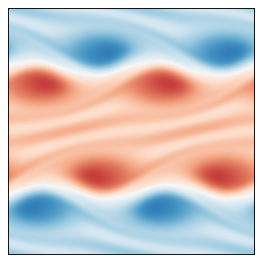

<Figure size 640x480 with 0 Axes>

         142518 function calls (141610 primitive calls) in 13.584 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    11/10    0.001    0.000   13.301    1.330 base_events.py:1966(_run_once)
  249/248    3.570    0.014   13.238    0.053 {built-in method time.sleep}
     5002    6.218    0.001    6.255    0.001 _utils.py:52(_Xfftn)
     3000    0.014    0.000    3.881    0.001 numpy_fft.py:281(ifftn)
     2000    0.634    0.000    3.239    0.002 navier_stokes_spectral_pyfftw_algo_optim_vortex.py:50(apply_dealias)
     2002    0.198    0.000    2.671    0.001 numpy_fft.py:246(fftn)
     1000    0.635    0.001    1.870    0.002 navier_stokes_spectral_pyfftw_algo_optim_vortex.py:45(curl)
     1000    0.753    0.001    0.753    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex.py:26(diffusion_solve)
     1000    0.626    0.001    0.626    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex.py:40(div)
     1000    0.600  

In [4]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_algo_optim_vortex.py

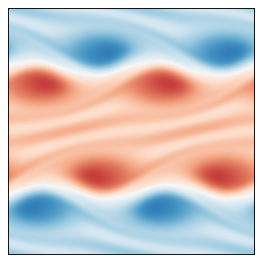

<Figure size 640x480 with 0 Axes>

         57072 function calls (56196 primitive calls) in 12.293 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000   12.069   12.069 {built-in method builtins.exec}
  224/223    4.939    0.022   11.368    0.051 {built-in method time.sleep}
       11    0.001    0.000   10.407    0.946 base_events.py:1966(_run_once)
     2000    2.447    0.001    2.447    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py:52(apply_dealias)
     1000    2.147    0.002    2.147    0.002 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py:45(curl)
      2/1    0.152    0.076    1.697    1.697 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py:1(<module>)
     1000    0.982    0.001    0.982    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py:26(diffusion_solve)
     1000    0.652    0.001    0.652    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py:40(div)
 

In [5]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned.py

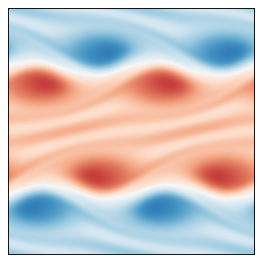

<Figure size 640x480 with 0 Axes>

         54703 function calls (53827 primitive calls) in 5.170 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.036    0.018    5.154    5.154 {built-in method builtins.exec}
    96/95    2.422    0.025    4.996    0.053 {built-in method time.sleep}
      2/1    0.002    0.001    1.931    1.931 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py:1(<module>)
     2000    1.162    0.001    1.162    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py:52(apply_dealias)
     1000    0.914    0.001    0.914    0.001 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py:45(curl)
     1000    0.279    0.000    0.279    0.000 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py:40(div)
     1000    0.253    0.000    0.253    0.000 navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py:21(poisson_solve)
        1    0.029    0.029    0.142    0.142 navier_sto

In [3]:
%run -m cProfile -s cumtime cython/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py

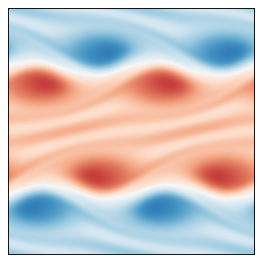

<Figure size 640x480 with 0 Axes>

Wrote profile results to 'cython/profilings/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py.lprof'
Timer unit: 1 s

Total time: 0 s
File: cython/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py
Function: poisson_solve at line 27

Line #      Hits         Time  Per Hit   % Time  Line Contents
    27                                           @profile
    28                                           def poisson_solve(rho_hat, kSq_inv):
    29                                               """solve the Poisson equation, given source field rho"""
    30                                               return -rho_hat * kSq_inv

Total time: 0 s
File: cython/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py
Function: div at line 47

Line #      Hits         Time  Per Hit   % Time  Line Contents
    47                                           @profile
    48                                           def div(vx_hat, vy_hat, ikx, iky):
    49            

In [1]:
%run -m kernprof -l -v -r -u 1 -o cython/profilings/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py.lprof cython/navier_stokes_spectral_pyfftw_algo_optim_vortex_planned_real.py